In [2]:
import os
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
import spacy

from tqdm.auto import tqdm
import re

from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import lightgbm as lgb
from sklearn.dummy import DummyClassifier

from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample

from textblob import TextBlob

from googleapiclient.discovery import build

from dotenv import load_dotenv

KeyboardInterrupt: 

## Reading Dataset

In [ ]:
dataset_path = os.path.join('..', 'datasets', 'archive')

comments = pd.read_csv(
    os.path.join(dataset_path, 'UScomments.csv'),
    on_bad_lines='skip',
    encoding='utf-8',
    low_memory=False
)
videos = pd.read_csv(
    os.path.join(dataset_path, 'USvideos.csv'), 
    on_bad_lines='skip', 
    encoding='utf-8')

videos_latest = pd.read_csv(
    os.path.join(dataset_path, 'USvideos_latest.csv'), 
    on_bad_lines='skip', 
    encoding='utf-8')

In [ ]:
display(comments.head()) # Display the first few rows of the dataset
display(comments.info()) # Display the information about the dataset

,video_id,comment_text,likes,replies
0,XpVt6Z1Gjjo,Logan Paul it's yo big day ‼️‼️‼️,4,0
1,XpVt6Z1Gjjo,I've been following you from the start of your...,3,0
2,XpVt6Z1Gjjo,Say hi to Kong and maverick for me,3,0
3,XpVt6Z1Gjjo,MY FAN . attendance,3,0
4,XpVt6Z1Gjjo,trending 😉,3,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691400 entries, 0 to 691399
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   video_id      691400 non-null  object
 1   comment_text  691374 non-null  object
 2   likes         691400 non-null  object
 3   replies       691400 non-null  object
dtypes: object(4)
memory usage: 21.1+ MB


None

In [ ]:
comments.loc[comments['comment_text'].isna()]  # Filter rows based on condition

,video_id,comment_text,likes,replies
1417,1L7JFN7tQLs,NaN,0,0
76134,7YAAyUFL1GQ,NaN,0,0
215218,KUCHBBCj77I,NaN,0,0
234226,KUCHBBCj77I,NaN,0,0
306019,s3Hk_lDw5yo,NaN,0,0
332811,zrOHeEA14kQ,NaN,0,0
357506,zmg9tVaMVd4,NaN,0,0
379582,zmg9tVaMVd4,NaN,0,0
403013,9eea7_7OBZQ,NaN,0,0
425238,6l5P7jHUcjI,NaN,0,0


In [ ]:
comments.dropna(inplace=True) # Drop rows with null values

In [ ]:
comments.info() # Check the data types and null values

<class 'pandas.core.frame.DataFrame'>
Index: 691374 entries, 0 to 691399
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   video_id      691374 non-null  object
 1   comment_text  691374 non-null  object
 2   likes         691374 non-null  object
 3   replies       691374 non-null  object
dtypes: object(4)
memory usage: 26.4+ MB


## Splitting into Training and Test Set
---

In [ ]:
# Split the dataset
train_comments_nltk, test_comments_nltk = train_test_split(comments, test_size=0.2, random_state=42)
comments_dummy_nltk = comments.copy() # Create a copy of the comments DataFrame to use for dummy model (TextBlob)

In effort to minimize data leakage, the comments dataset was split and preprocessing will be applied to each set separately.

## NLTK
---

### Text Cleaning & Tokenization

In [ ]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to C:\Users\New
[nltk_data]     Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\New
[nltk_data]     Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\New
[nltk_data]     Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
def clear_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r"(@\S+|#\S+|http\S+|[^a-zA-Z\s])", " ", text)  # Combine regex patterns to remove mentions, hashtags, URLs, and special characters
    text = re.sub(r"\s+", " ", text).strip()  # Replace multiple spaces with a single space and strip leading/trailing spaces
    return text

In [ ]:
train_comments_nltk['comment_text'] = train_comments_nltk['comment_text'].astype(str).apply(clear_text).apply(word_tokenize)
test_comments_nltk['comment_text'] = test_comments_nltk['comment_text'].astype(str).apply(clear_text).apply(word_tokenize)
comments_dummy_nltk['comment_text'] = comments_dummy_nltk['comment_text'].astype(str).apply(clear_text).apply(word_tokenize)

### Stop Word Removal/Lemmatization

In [ ]:
stop_words = set(stopwords.words('english')) # Set of English stop words
lemmatizer = WordNetLemmatizer() # Initialize the lemmatizer

# Remove stop words and apply lemmatization to the tokenized text
train_comments_nltk['tokenized_text'] = train_comments_nltk['comment_text'].apply(lambda tokens: [word for word in tokens if word not in stop_words])
train_comments_nltk['tokenized_text'] = train_comments_nltk['comment_text'].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])

test_comments_nltk['tokenized_text'] = test_comments_nltk['comment_text'].apply(lambda tokens: [word for word in tokens if word not in stop_words])
test_comments_nltk['tokenized_text'] = test_comments_nltk['comment_text'].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])

comments_dummy_nltk['tokenized_text'] = comments_dummy_nltk['comment_text'].apply(lambda tokens: [word for word in tokens if word not in stop_words])
comments_dummy_nltk['tokenized_text'] = comments_dummy_nltk['comment_text'].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])

In [ ]:
train_comments_nltk['tokenized_text'] = train_comments_nltk['tokenized_text'].apply(lambda tokens: ' '.join(tokens))
test_comments_nltk['tokenized_text'] = test_comments_nltk['tokenized_text'].apply(lambda tokens: ' '.join(tokens))
comments_dummy_nltk['tokenized_text'] = comments_dummy_nltk['tokenized_text'].apply(lambda tokens: ' '.join(tokens))

## Creating Like-to-Dislike Ratio
---

In [ ]:
total_interactions = videos['likes'] + videos['dislikes'] # Calculate total interactions
videos['l_d_ratio'] = videos['likes'] / total_interactions # Calculate the like-dislike ratio
videos.head(10)

,video_id,title,channel_title,category_id,tags,views,likes,dislikes,comment_total,thumbnail_link,date,l_d_ratio
0,XpVt6Z1Gjjo,1 YEAR OF VLOGGING -- HOW LOGAN PAUL CHANGED Y...,Logan Paul Vlogs,24,logan paul vlog|logan paul|logan|paul|olympics...,4394029,320053,5931,46245,https://i.ytimg.com/vi/XpVt6Z1Gjjo/default.jpg,13.09,0.981806
1,K4wEI5zhHB0,iPhone X — Introducing iPhone X — Apple,Apple,28,Apple|iPhone 10|iPhone Ten|iPhone|Portrait Lig...,7860119,185853,26679,0,https://i.ytimg.com/vi/K4wEI5zhHB0/default.jpg,13.09,0.874471
2,cLdxuaxaQwc,My Response,PewDiePie,22,[none],5845909,576597,39774,170708,https://i.ytimg.com/vi/cLdxuaxaQwc/default.jpg,13.09,0.935471
3,WYYvHb03Eog,Apple iPhone X first look,The Verge,28,apple iphone x hands on|Apple iPhone X|iPhone ...,2642103,24975,4542,12829,https://i.ytimg.com/vi/WYYvHb03Eog/default.jpg,13.09,0.846123
4,sjlHnJvXdQs,iPhone X (parody),jacksfilms,23,jacksfilms|parody|parodies|iphone|iphone x|iph...,1168130,96666,568,6666,https://i.ytimg.com/vi/sjlHnJvXdQs/default.jpg,13.09,0.994158
5,cMKX2tE5Luk,The Disaster Artist | Official Trailer HD | A24,A24,1,a24|a24 films|a24 trailers|independent films|t...,1311445,34507,544,3040,https://i.ytimg.com/vi/cMKX2tE5Luk/default.jpg,13.09,0.984480
6,8wNr-NQImFg,"The Check In: HUD, Ben Carson and Hurricanes",Late Night with Seth Meyers,23,Late night|Seth Meyers|check in|hud|Ben Carson...,666169,9985,297,1071,https://i.ytimg.com/vi/8wNr-NQImFg/default.jpg,13.09,0.971115
7,_HTXMhKWqnA,iPhone X Impressions & Hands On!,Marques Brownlee,28,iPhone X|iphone x|iphone 10|iPhone X impressio...,1728614,74062,2180,15297,https://i.ytimg.com/vi/_HTXMhKWqnA/default.jpg,13.09,0.971407
8,_ANP3HR1jsM,ATTACKED BY A POLICE DOG!!,RomanAtwoodVlogs,22,Roman Atwood|Roman|Atwood|roman atwood vlogs|f...,1338533,69687,678,5643,https://i.ytimg.com/vi/_ANP3HR1jsM/default.jpg,13.09,0.990365
9,zgLtEob6X-Q,Honest Trailers - The Mummy (2017),Screen Junkies,1,screenjunkies|screen junkies|screenjunkies new...,1056891,29943,878,4046,https://i.ytimg.com/vi/zgLtEob6X-Q/default.jpg,13.09,0.971513


## Creating Positive-to-Negative Comments Ratio
---

In [ ]:
def get_sentiment(text):
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity  # -1 (negative) to 1 (positive)

    # Binary classification
    sentiment_class = "positive" if polarity > 0 else "negative"

    return sentiment_class

In [ ]:
comments_dummy_nltk.drop(columns=['comment_text'], inplace=True) # Drop the original comment text column

In [ ]:
comments_dummy_nltk['sentiment_ratio'] = comments_dummy_nltk['tokenized_text'].apply(get_sentiment) # Apply the sentiment function to the tokenized text
comments_dummy_nltk.head(10) # Display the first 10 rows of the comments_dummy DataFrame

,video_id,likes,replies,tokenized_text,sentiment_ratio
0,XpVt6Z1Gjjo,4,0,logan paul it s yo big day,negative
1,XpVt6Z1Gjjo,3,0,i ve been following you from the start of your...,negative
2,XpVt6Z1Gjjo,3,0,say hi to kong and maverick for me,negative
3,XpVt6Z1Gjjo,3,0,my fan attendance,negative
4,XpVt6Z1Gjjo,3,0,trending,negative
5,XpVt6Z1Gjjo,3,0,on trending ayyeeeee,negative
6,XpVt6Z1Gjjo,4,0,the end though,negative
7,XpVt6Z1Gjjo,3,0,trending,negative
8,XpVt6Z1Gjjo,3,0,happy one year vlogaversary,positive
9,XpVt6Z1Gjjo,0,0,you and your shit brother may have single hand...,negative


In [ ]:
sentiment_count = comments_dummy_nltk.groupby('video_id')['sentiment_ratio'].value_counts().unstack().fillna(0) # Count the occurrences of each sentiment class
sentiment_count['p_n_ratio'] = sentiment_count['positive'] / (sentiment_count['positive'] + sentiment_count['negative']) # Calculate the sentiment ratio (normalized)

In [ ]:
dummy_vid_stats = videos.merge(sentiment_count, on='video_id') # Merge the sentiment count with the videos DataFrame
dummy_vid_stats.dropna(inplace=True) # Drop rows with NaN values
dummy_vid_stats = dummy_vid_stats[['video_id', 'title', 'l_d_ratio', 'p_n_ratio']] # Select relevant columns

In [ ]:
dummy_vid_stats.head() # Display the information about the dummy_vid_stats DataFrame

,video_id,title,l_d_ratio,ratio
0,XpVt6Z1Gjjo,1 YEAR OF VLOGGING -- HOW LOGAN PAUL CHANGED Y...,0.981806,0.310000
1,cLdxuaxaQwc,My Response,0.935471,0.349186
2,WYYvHb03Eog,Apple iPhone X first look,0.846123,0.355000
3,sjlHnJvXdQs,iPhone X (parody),0.994158,0.385000
4,cMKX2tE5Luk,The Disaster Artist | Official Trailer HD | A24,0.984480,0.418571


## Relationship between Like-to-Dislike Ratio & Positive-to-Negative Ratio
---

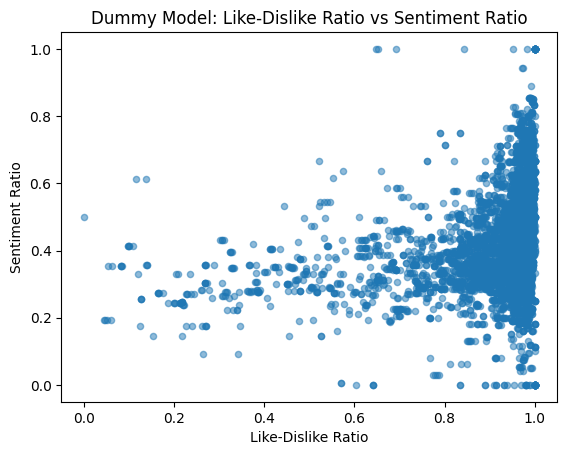

In [ ]:
dummy_vid_stats.plot.scatter(x='l_d_ratio', y='p_n_ratio', alpha=0.5) # Scatter plot of like-dislike ratio vs sentiment ratio
plt.title('Dummy Model: Like-Dislike Ratio vs Sentiment Ratio') # Title of the plot
plt.xlabel('Like-Dislike Ratio') # X-axis label
plt.ylabel('Sentiment Ratio') # Y-axis label
plt.show() # Show the plot

In [ ]:
dummy_vid_stats[['l_d_ratio', 'p_n_ratio']].corr() # Calculate the correlation between the like-dislike ratio and the sentiment ratio

,l_d_ratio,ratio
l_d_ratio,1.000000,0.278284
ratio,0.278284,1.000000


After analyzing the metrics for the listed YouTube videos, we observed a weak correlation between the Like-Dislike ratio and the Sentiment ratio. As a video accumulates more likes, the proportion of positive comments tends to increase.

This trend may be partially influenced by YouTube's algorithm—videos with higher engagement are more likely to appear in users' feeds, increasing visibility and the chance of receiving comments.

However, since the correlation is weak, the relationship between likes and comment sentiment is only marginal. Other underlying factors likely play a bigger role in this dynamic.

The key takeaway? Early on, you may see more likes than comments, but with consistent posting, positive engagement (including comments) should grow over time—though not all comments will be positive.

## Model Training
---

In [ ]:
# Apply the function to the 'tokenized_text' column
train_comments_nltk['sentiment_class'] = train_comments_nltk['tokenized_text'].apply(get_sentiment)

test_comments_nltk['sentiment_class'] = test_comments_nltk['tokenized_text'].apply(get_sentiment)

### Class Imbalance

sentiment_class
negative    0.564243
positive    0.435757
Name: proportion, dtype: float64
sentiment_class
negative    312082
positive    241017
Name: count, dtype: int64


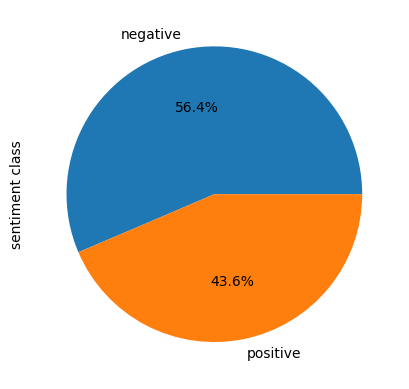

In [ ]:
# numerical/visual representation of composition of the class proportions before upsampling
train_comments_nltk.groupby('sentiment_class').size().plot(kind='pie', y='sentiment_class', label='sentiment class', autopct='%1.1f%%')
print(train_comments_nltk['sentiment_class'].value_counts(normalize = True)) # Check the target distribution
print(train_comments_nltk['sentiment_class'].value_counts())

In [ ]:
# upsampling used to address class imbalance
majority = train_comments_nltk[train_comments_nltk['sentiment_class'] == 'negative'] # Majority class (negative sentiment)
minority = train_comments_nltk[train_comments_nltk['sentiment_class'] == 'positive'] # Minority class (positive sentiment)
minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=42) # Upsample minority class
# Combine majority class with upsampled minority class
train_comments_nltk = pd.concat([majority, minority_upsampled])

sentiment_class
negative    0.5
positive    0.5
Name: proportion, dtype: float64
sentiment_class
negative    312082
positive    312082
Name: count, dtype: int64


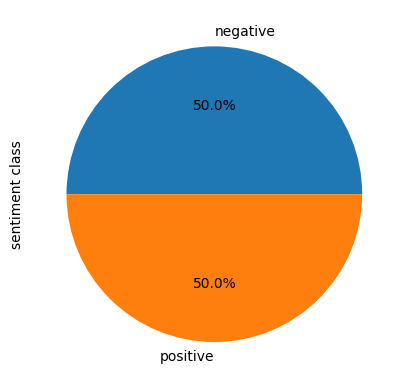

In [ ]:
# numerical/visual representation of composition of the class proportions before upsampling
train_comments_nltk.groupby('sentiment_class').size().plot(kind='pie', y='sentiment_class', label='sentiment class', autopct='%1.1f%%')
print(train_comments_nltk['sentiment_class'].value_counts(normalize = True)) # Check the target distribution
print(train_comments_nltk['sentiment_class'].value_counts())

In [ ]:
# Ensure the correct usage of TfidfVectorizer methods
vectorizer = TfidfVectorizer() # Initialize the vectorizer
X_train_vect = vectorizer.fit_transform(train_comments_nltk['tokenized_text']) # Fit and transform the training data
X_test_vect = vectorizer.transform(test_comments_nltk['tokenized_text']) # Transform the test data

In [ ]:
# Target variable encoding
le = LabelEncoder() # Initialize the label encoder
y_train = le.fit_transform(train_comments_nltk['sentiment_class']) # Fit and transform the training data
y_test = le.transform(test_comments_nltk['sentiment_class']) # Transform the test data

### Dummy Classifier Model

In [ ]:
dummy_model = DummyClassifier(strategy='uniform') # Initialize the dummy classifier w/ uniform strategy

dummy_model.fit(X_train_vect, y_train) # Fit the dummy model to the training data
dummy_y_pred = dummy_model.predict(X_test_vect) # Predict the test data

# Calculate the ROC AUC score
dummy_auc = roc_auc_score(y_test, dummy_y_pred) # Calculate the ROC AUC score for the dummy model
print(f"Dummy Model ROC AUC Score: {dummy_auc:.4f}") # Print the ROC AUC score

Dummy Model ROC AUC Score: 0.5020


Class imbalance is a common challenge in classification tasks, typically requiring manual correction through oversampling or undersampling, which is done in this notebook. However, logistic regression, along with the latter models offer a built-in solution to address this issue innately, efficiently managing uneven class distributions without additional sampling steps.

### Logistic Regression

In [ ]:
log_model = LogisticRegression(max_iter=200)  # Initialize the logistic regression model
log_model.fit(X_train_vect, y_train)  # Fit the model to the training data

# Make predictions on the test data
y_pred_encoded = log_model.predict(X_test_vect)  # Make predictions on the test data

# Calculate the ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_encoded)  # Calculate the ROC-AUC score
print(f"ROC-AUC Score: {roc_auc:.4f}")  # Print the ROC-AUC score

ROC-AUC Score: 0.9675


### Decision Tree Classifier

In [ ]:
# Initialize the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)  # Initialize the decision tree model

# Fit the model to the training data
dt_model.fit(X_train_vect, y_train)  # Fit the model to the training data

# Make predictions on the test data
y_pred_dt_encoded = dt_model.predict(X_test_vect)  # Make predictions on the test data

# Generate the AUC-ROC score for Decision Tree
auc_score = roc_auc_score(y_test, y_pred_dt_encoded)  # Calculate the AUC-ROC score
print(f"ROC-AUC Score for Decision Tree: {auc_score}")  # Print the AUC-ROC score

ROC-AUC Score for Decision Tree: 0.9705528508267491


### LightGBM Classifier

In [ ]:
# Initialize the LightGBM Classifier
lgb_model = lgb.LGBMClassifier(force_col_wise=True, random_state=42)  # Initialize the LightGBM model

# Fit the model to the training data
lgb_model.fit(X_train_vect, y_train)  # Fit the model to the training data

# Make predictions on the test data
y_pred_lgb_encoded = lgb_model.predict(X_test_vect)  # Make predictions on the test data

# Generate the ROC-AUC score for LightGBM
roc_auc_lgb = roc_auc_score(y_test, y_pred_lgb_encoded)  # Calculate the ROC-AUC score
print(f"ROC-AUC Score for LightGBM: {roc_auc_lgb}")  # Print the ROC-AUC score

[LightGBM] [Info] Number of positive: 312082, number of negative: 312082
[LightGBM] [Info] Total Bins 364261
[LightGBM] [Info] Number of data points in the train set: 624164, number of used features: 15806
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\New Owner\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ROC-AUC Score for LightGBM: 0.9388332855540021


After vectorizing the features and training the chosen models, the metric used to assess the model performance was the ROC-AUC score considered for interepretability, comparatability and the fact that this measure a model's general performance. With that being said, the model that produced the highest overall ROC-AUC score was the Decision Tree Classifier model with a score of 0.97. 

### Visual Representation of ROC-AUC Metric


c:\Users\New Owner\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


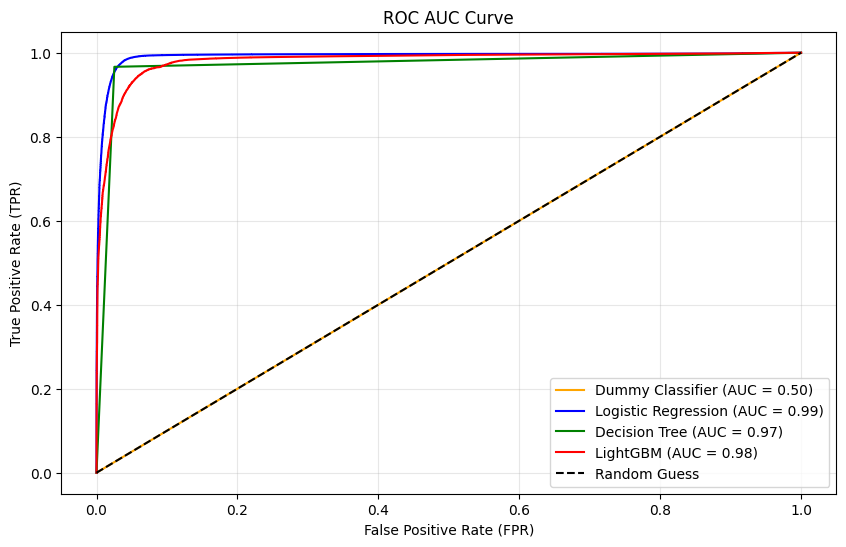

In [ ]:
# Generate ROC curve data for Dummy Classifier
y_pred_dummy_proba = dummy_model.predict_proba(X_test_vect)[:, 1] 
fpr_dummy, tpr_dummy, _ = roc_curve(y_test, y_pred_dummy_proba)
roc_auc_dummy = auc(fpr_dummy, tpr_dummy)

# Generate ROC curve data for Logistic Regression
y_pred_proba_log = log_model.predict_proba(X_test_vect)[:, 1] 
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_log)
roc_auc_log = auc(fpr_log, tpr_log)

# Generate ROC curve data for Decision Tree
y_pred_proba_dt = dt_model.predict_proba(X_test_vect)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Generate ROC curve data for LightGBM
y_pred_proba_lgb = lgb_model.predict_proba(X_test_vect)[:, 1]
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_pred_proba_lgb)
roc_auc_lgb = auc(fpr_lgb, tpr_lgb)

# Plot the ROC curves
plt.figure(figsize=(10, 6))
plt.plot(fpr_dummy, tpr_dummy, label=f'Dummy Classifier (AUC = {roc_auc_dummy:.2f})', color='orange') 
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_log:.2f})', color='blue')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})', color='green')
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {roc_auc_lgb:.2f})', color='red')

# Plot the diagonal line (random guess)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Add labels, legend, and title
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC AUC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

When looking at this plot, it's best to start with the line running diagonally from the bottom left to the top right, this line indicates a model that predicts randomly, which is used as a baseline to reference the curves. You can see the Dummy Classifier is on par with this dotted diagonal line because it's derived from random guessing.

While the three curves are virtually the same with marginal difference, the way to interpret them to see which model is the best is by the height of the curve in relation to the diagonal line. The higher the curve, the greater the TPR value and the better the model's quality. With that being said, the curve that is higher is that of the logistic regression with the decision tree classifier trailing behind.

## Video Comment Sentiment Ratio Prediction
---

After selecting the best model for sentiment prediction based on the ROC-AUC score, a new dataset will be created that will hold the comments related to a new video. Therefore, this information will be collected via the latest version of the US Videos csv file, which holds more videos than the original.

Note: this csv file includes video statistics of the latest trending videos. In other words, this csv file contains new video ids.

In [ ]:
# Verify that the video IDs in df are not present in videos
print('# of new video IDs that are not in the original videos df:', videos_latest[~videos_latest["video_id"].isin(videos["video_id"])].shape[0]) # Check the number of rows in df that are not in videos
print('# of new video IDs that are in the original videos df:', videos_latest[videos_latest["video_id"].isin(videos["video_id"])].shape[0]) # Check the number of rows in df that are in videos

# of new video IDs that are not in the original videos df: 40949
# of new video IDs that are in the original videos df: 0


In [ ]:
new_vid_id = videos_latest[25] # Sample a random video ID from the DataFrame to be used for prediction
print('New video ID:', new_vid_id) # Print the random video ID

NameError: name 'videos_latest' is not defined

The following couple of next cells focus on building a function that pulls new comments from the referenced new video id via a YouTube Data API.

The steps to achieving this is as follows:
1. Setting up an API client
2. Creating a function the pulls the comments via YouTube Data API
3. Runnining the function using a new video id

In [ ]:
# Set up the YouTube Data API client
load_dotenv()
API_KEY = os.getenv("API_KEY")
youtube = build('youtube', 'v3', developerKey=API_KEY)

In [ ]:
def fetch_comments(video_id, max_results=100):
    comments = []
    next_page_token = None

    while True:
        response = youtube.commentThreads().list(
            part='snippet',
            videoId=video_id,
            maxResults=max_results,
            pageToken=next_page_token
        ).execute()

        for item in response['items']:
            comment = item['snippet']['topLevelComment']['snippet']
            comments.append({
                'author': comment['authorDisplayName'],
                'text': comment['textDisplay'],
                'like_count': comment['likeCount'],
                'published_at': comment['publishedAt']
            })

        next_page_token = response.get('nextPageToken')
        if not next_page_token:
            break
        
    return pd.DataFrame(comments)

In [ ]:
# Fetch comments for the new video ID
comments_df = fetch_comments(new_vid_id)

# Display the first few rows of the DataFrame
display(comments_df.head())

,author,text,like_count,published_at
0,@SethMartinIsABurger,"Dude, I can&#39;t believe how far you&#39;ve c...",1145,2017-11-12T14:24:49Z
1,@gladlee7520,"<a href=""https://www.youtube.com/watch?v=dRpNZ...",0,2024-11-11T09:50:52Z
2,@michaelad48,JULIA EON HANDS DOWN,0,2024-10-13T13:20:49Z
3,@Zeus-rw7df,Spaghetti burrito and spaghetti beef wellingto...,0,2024-04-23T02:54:30Z
4,@calamedisgaunt916,for everyone that didn&#39;t see the pole befo...,0,2023-09-23T13:53:03Z


### Preprocessing New Comments

In [ ]:
comments_df['text'] = comments_df['text'].astype(str).apply(clear_text).apply(word_tokenize) # Preprocess the comments
comments_df['text'] = comments_df['text'].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])
comments_df['text'] = comments_df['text'].apply(lambda tokens: ' '.join(tokens)) 

In [ ]:
comments_df = comments_df['text']
comments_df

### Creating Sentiment Predictions using Trained Model

In [ ]:
# Transform the new text data using the existing vectorizer
X_new = vectorizer.transform(comments_df)

# Predict sentiment using the Decision Tree model
sentiment_pred = dt_model.predict(X_new)

In [ ]:
comments_df = comments_df.reset_index(drop=True) # Reset the index of the comments DataFrame
comments_df = pd.DataFrame(comments_df) # Convert the comments DataFrame to a DataFrame
comments_df = pd.concat([comments_df, pd.Series(sentiment_pred)], axis=1) # Concatenate the predictions with the original DataFrame
comments_df.columns = ['text', 'sentiment'] # Rename the columns
comments_df['sentiment'] = le.inverse_transform(comments_df['sentiment'])

In [ ]:
new_video_id_sr = pd.Series(rand_vid_id)
series = pd.Series([rand_vid_id]*len(comments_df))
merged_senti_pred = pd.concat([series, comments_df], axis=1)
merged_senti_pred.columns = ['video_id', 'text', 'sentiment'] # Rename the columns
merged_senti_pred.head() # Display the first few rows of the merged sentiment predictions DataFrame

,video_id,text,sentiment
0,dRpNZV18N_g,dude i can believe how far you come it serious...,positive
1,dRpNZV18N_g,a href the jp scream cut,negative
2,dRpNZV18N_g,julia eon hand down,negative
3,dRpNZV18N_g,spaghetti burrito and spaghetti beef wellingto...,positive
4,dRpNZV18N_g,for everyone that didn see the pole before you...,negative


### Calculating Positive-to-Negative Ratio for Sentiment Predictions

In [ ]:
new_sentiment_count = merged_senti_pred.groupby('video_id')['sentiment'].value_counts().unstack().fillna(0) # Count the occurrences of each sentiment class
new_sentiment_count['p_n_ratio'] = new_sentiment_count['positive'] / (new_sentiment_count['positive'] + new_sentiment_count['negative']) # Calculate the sentiment ratio (normalized)

In [ ]:
new_sentiment_count

sentiment,negative,positive,ratio
video_id,,,
dRpNZV18N_g,1111,597,0.349532


## Findings
---